# ОНПД. Лабораторна робота №4

In [150]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [151]:
mydata = pd.read_csv("house_prices_dataset.csv")
mydata = mydata[mydata['price'] > 200].copy()

In [152]:
mydata.head()

,square_feet,num_rooms,age,distance_to_city(km),price
0,2248.357077,3,92,22.997972,200374.090410
1,1930.867849,2,22,13.984254,268784.847337
2,2323.844269,6,33,21.500945,315020.857676
3,2761.514928,3,63,10.343638,355111.468459
4,1882.923313,7,54,25.485200,234197.123903


In [153]:
mydata.tail()

,square_feet,num_rooms,age,distance_to_city(km),price
9995,2650.551032,7,9,18.126034,431344.267823
9996,1000.827516,2,53,24.479692,6650.271134
9997,1647.341638,5,80,2.189312,233698.384301
9998,2247.882787,6,73,27.931014,280766.827379
9999,2322.194227,7,73,10.595721,342895.309114


In [154]:
mydata.shape

(9962, 5)

In [155]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9962 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   square_feet           9962 non-null   float64
 1   num_rooms             9962 non-null   int64  
 2   age                   9962 non-null   int64  
 3   distance_to_city(km)  9962 non-null   float64
 4   price                 9962 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 467.0 KB


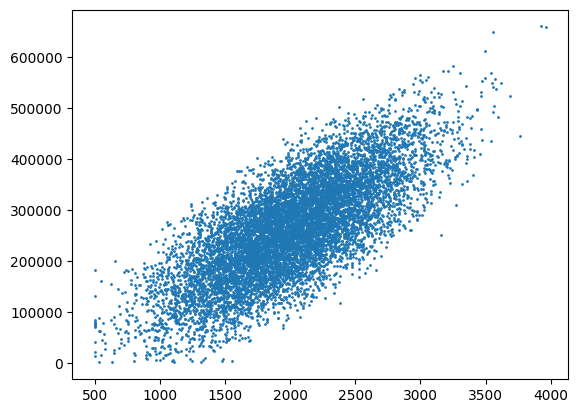

In [156]:
plt.scatter(mydata["square_feet"],mydata["price"],s=1)

In [157]:
X = mydata["square_feet"].values.reshape(-1, 1)
Y = mydata["price"].values.reshape(-1, 1)

In [158]:
from sklearn.model_selection import train_test_split
X_train, X_cv, y_train, y_cv = train_test_split(X, Y, test_size=0.3)


In [159]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [160]:
predictions_train = lin_reg.predict(X_train)

In [161]:
from sklearn.metrics import mean_squared_error
mse_train = mean_squared_error(y_train, predictions_train)
rmse_train = np.sqrt(mse_train)

In [162]:
predictions_cv = lin_reg.predict(X_cv)

In [163]:
from sklearn.metrics import r2_score
mse_cv = mean_squared_error(y_cv, predictions_cv)
rmse_cv = np.sqrt(mse_cv)
r2_cv = r2_score(y_cv, predictions_cv)

In [164]:
print(f"Середньоквадратична помилка на тренуванні (RMSE): {rmse_train:.2f}")
print(f"Середньоквадратична помилка на крос-валідації (RMSE): {rmse_cv:.2f}")
print(f"Коефіцієнт детермінації R2 Score: {r2_cv:.4f}")

Середньоквадратична помилка на тренуванні (RMSE): 64395.39
Середньоквадратична помилка на крос-валідації (RMSE): 62906.84
Коефіцієнт детермінації R2 Score: 0.5774


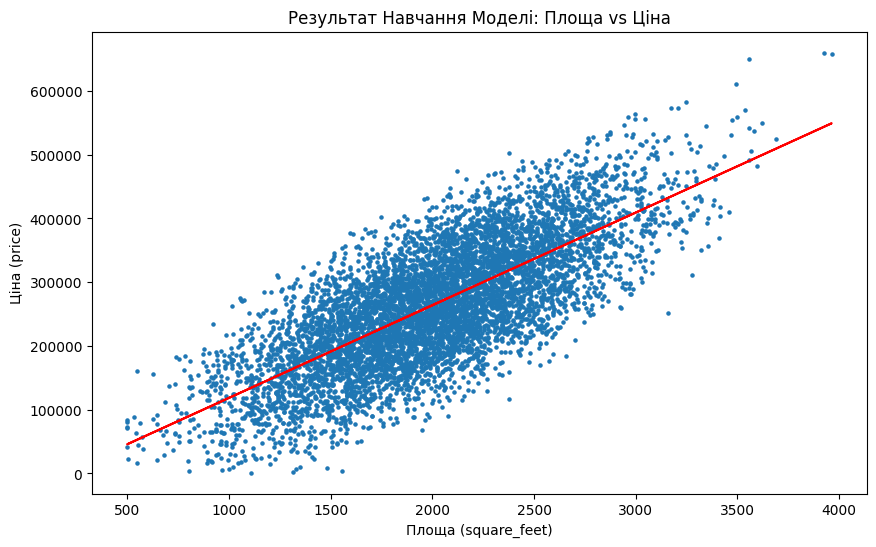

In [165]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, s=5, label='Фактичні дані')
plt.plot(X_train, predictions_train, color='red', label='Лінія регресії')
plt.title('Результат Навчання Моделі: Площа vs Ціна')
plt.xlabel('Площа (square_feet)')
plt.ylabel('Ціна (price)')
plt.show()

In [169]:
age_q1 = mydata['age'].quantile(0.4)
age_q2 = mydata['age'].quantile(0.6)
distance_q1 = mydata['distance_to_city(km)'].quantile(0.4)
distance_q2 = mydata['distance_to_city(km)'].quantile(0.6)
num_rooms_popular = mydata['num_rooms'].value_counts().nlargest(1).index.tolist()
mydata_filtered = mydata[
    (mydata['age'] >= age_q1) & (mydata['age'] <= age_q2) &
    (mydata['distance_to_city(km)'] >= distance_q1) & (mydata['distance_to_city(km)'] <= distance_q2) &
    (mydata['num_rooms'].isin(num_rooms_popular))
].copy()

In [170]:
X = mydata_filtered["square_feet"].values.reshape(-1, 1)
Y = mydata_filtered["price"].values.reshape(-1, 1)
X_train, X_cv, y_train, y_cv = train_test_split(X, Y, test_size=0.3)
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
predictions_train = lin_reg.predict(X_train)
mse_train = mean_squared_error(y_train, predictions_train)
rmse_train = np.sqrt(mse_train)
predictions_cv = lin_reg.predict(X_cv)
mse_cv = mean_squared_error(y_cv, predictions_cv)
rmse_cv = np.sqrt(mse_cv)
r2_cv = r2_score(y_cv, predictions_cv)
print(f"Середньоквадратична помилка на тренуванні (RMSE): {rmse_train:.2f}")
print(f"Середньоквадратична помилка на крос-валідації (RMSE): {rmse_cv:.2f}")
print(f"Коефіцієнт детермінації R2 Score: {r2_cv:.4f}")

Середньоквадратична помилка на тренуванні (RMSE): 19712.36
Середньоквадратична помилка на крос-валідації (RMSE): 26311.72
Коефіцієнт детермінації R2 Score: 0.8694


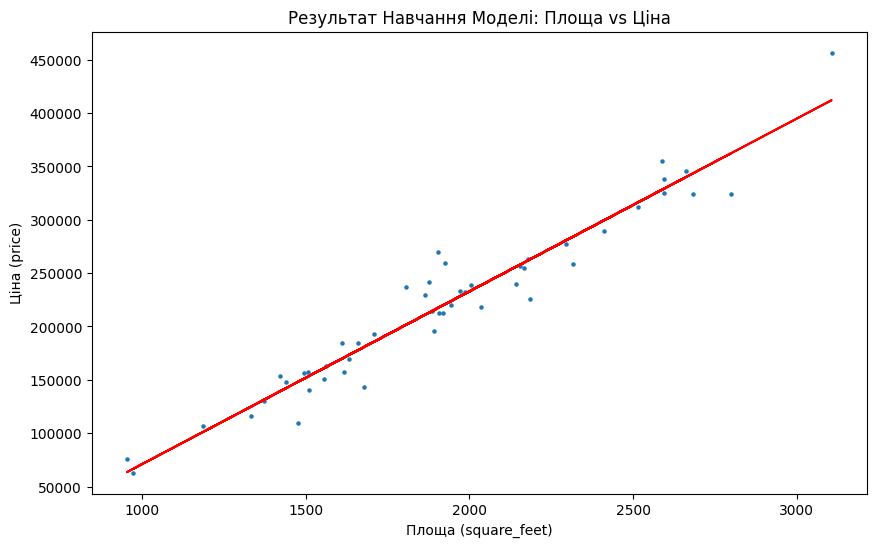

In [171]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, s=5, label='Фактичні дані')
plt.plot(X_train, predictions_train, color='red', label='Лінія регресії')
plt.title('Результат Навчання Моделі: Площа vs Ціна')
plt.xlabel('Площа (square_feet)')
plt.ylabel('Ціна (price)')
plt.show()